window_size: 14
prediction_horizon: 2
hidden_size: 14

Running on AirPassengers Dataset


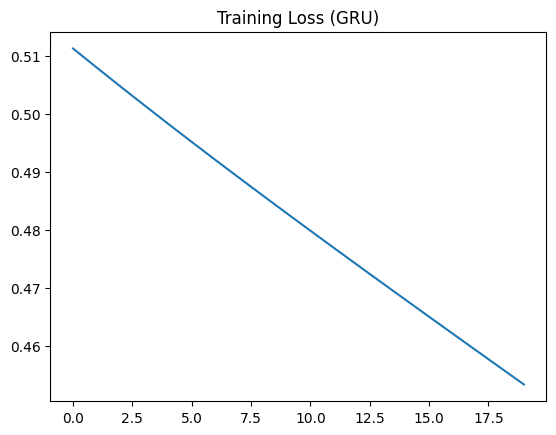

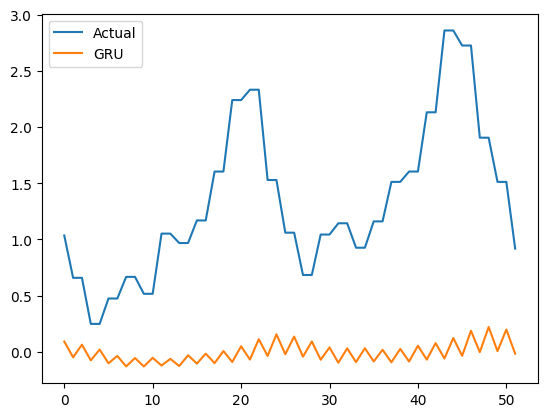

MLP: 0.6212327480316162 0.5777205228805542 0.7881831944615517
GRU: 2.23099946975708 1.342329978942871 1.4936530620452262
LSTM: 2.44948148727417 1.4160834550857544 1.5650819426707887
Transformer: 0.5851808786392212 0.5550663471221924 0.7649711619657444

Running on Electricity Dataset


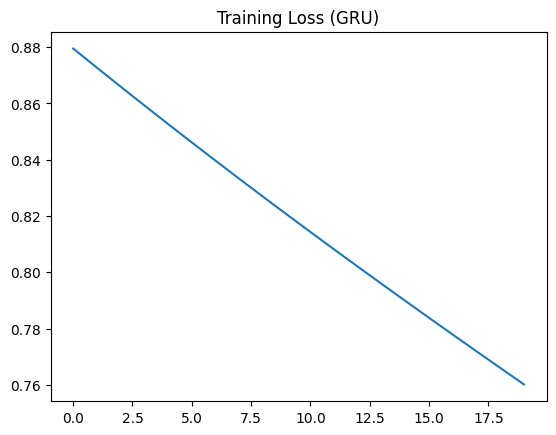

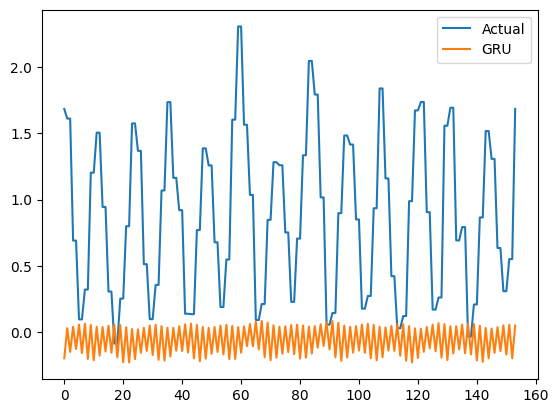

MLP: 0.4127926826477051 0.5116745233535767 0.6424894416624332
GRU: 1.2354722023010254 0.9334608316421509 1.111517972099878
LSTM: 1.1352901458740234 0.8813972473144531 1.065499951137504
Transformer: 0.35519641637802124 0.49641209840774536 0.5959835705604822

Ablation Study on Electricity Dataset
Window Size: 7


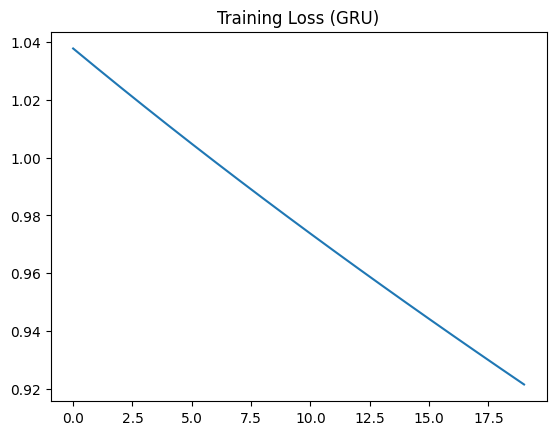

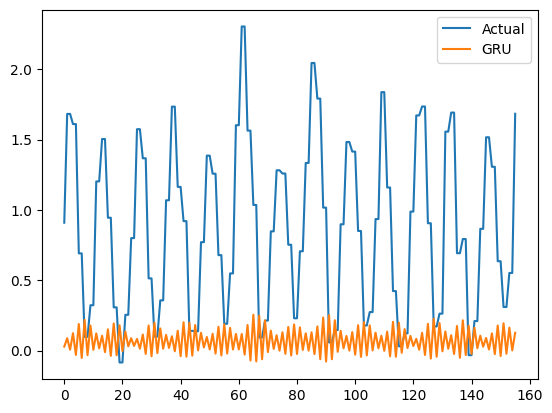

MLP: 0.49553701281547546 0.55243980884552 0.7039438989120337
GRU: 1.0264949798583984 0.8246586322784424 1.0131608854759437
LSTM: 1.157011866569519 0.8942701816558838 1.0756448608018907
Transformer: 0.41824477910995483 0.5334797501564026 0.6467184697454951
Window Size: 14


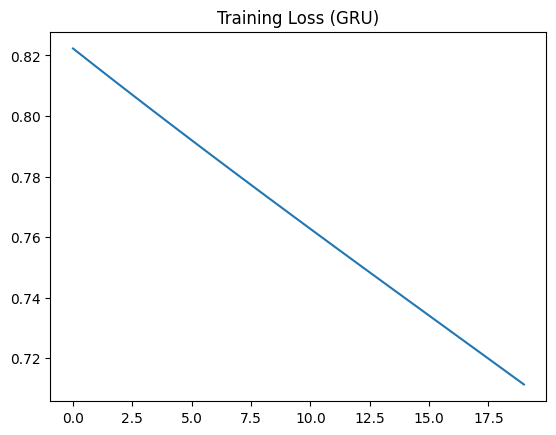

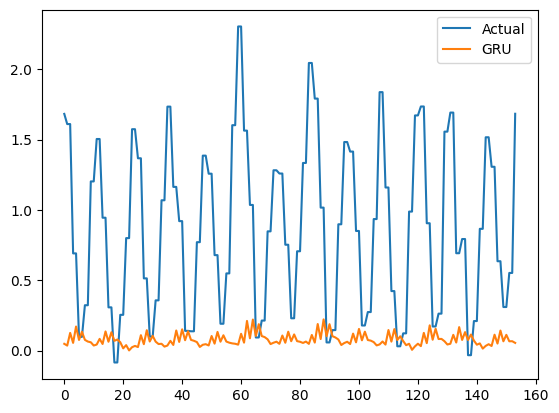

MLP: 0.5115732550621033 0.5672849416732788 0.7152434935475493
GRU: 0.9902948141098022 0.8031454086303711 0.9951355757432262
LSTM: 0.9112011194229126 0.7647817134857178 0.954568551452913
Transformer: 0.32513687014579773 0.4823896884918213 0.5702077429725044
Window Size: 28


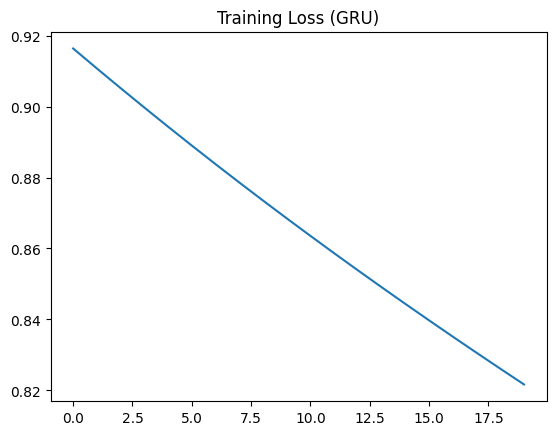

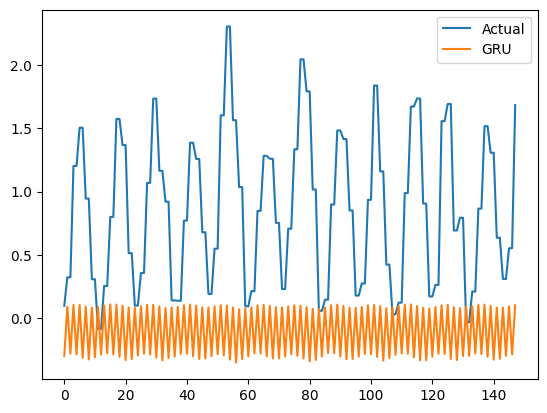

MLP: 0.34492480754852295 0.4736137390136719 0.5873029946701472
GRU: 1.3248385190963745 0.9719041585922241 1.1510162983626142
LSTM: 1.337700366973877 0.9922710657119751 1.156589973574852
Transformer: 0.33643943071365356 0.4828348159790039 0.5800339909985048


In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

df1 = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv")
df2 = pd.read_csv('/content/Electric_Production.csv')

roll = "102303313"
digits = [int(d) for d in roll]

window_size = (sum(digits) % 10) + 8
prediction_horizon = (int(roll[-2:]) % 3) + 1
hidden_size = (int(roll[:3]) % 16) + 8

print("window_size:", window_size)
print("prediction_horizon:", prediction_horizon)
print("hidden_size:", hidden_size)

data1 = df1.select_dtypes(include=[np.number]).iloc[:,0].values
data2 = df2.select_dtypes(include=[np.number]).iloc[:,0].values

data1 = (data1 - np.mean(data1)) / np.std(data1)
data2 = (data2 - np.mean(data2)) / np.std(data2)

def create_windows(data, window_size, horizon):
    X, y = [], []
    for i in range(len(data) - window_size - horizon):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size:i+window_size+horizon])
    return np.array(X), np.array(y)

def prepare(data):
    X, y = create_windows(data, window_size, prediction_horizon)
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    return (
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32),
        torch.tensor(X_test, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.float32)
    )

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(window_size, 64),
            nn.ReLU(),
            nn.Linear(64, prediction_horizon)
        )
    def forward(self, x):
        return self.net(x)

class CustomGRU(nn.Module):
    def __init__(self):
        super().__init__()
        self.Wz = nn.Linear(1 + hidden_size, hidden_size)
        self.Wr = nn.Linear(1 + hidden_size, hidden_size)
        self.Wh = nn.Linear(1 + hidden_size, hidden_size)
        self.fc = nn.Linear(hidden_size, prediction_horizon)

    def forward(self, x):
        batch_size = x.size(0)
        h = torch.zeros(batch_size, hidden_size)
        for t in range(x.size(1)):
            x_t = x[:, t].unsqueeze(1)
            combined = torch.cat((x_t, h), dim=1)
            z = torch.sigmoid(self.Wz(combined))
            r = torch.sigmoid(self.Wr(combined))
            combined_r = torch.cat((x_t, r * h), dim=1)
            h_tilde = torch.tanh(self.Wh(combined_r))
            h = (1 - z) * h + z * h_tilde
        return self.fc(h)

class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, prediction_horizon)

    def forward(self, x):
        x = x.unsqueeze(-1)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

class TransformerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_fc = nn.Linear(1, hidden_size)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_size, nhead=2, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(hidden_size, prediction_horizon)

    def forward(self, x):
        x = x.unsqueeze(-1)
        x = self.input_fc(x)
        out = self.transformer(x)
        return self.fc(out[:, -1, :])

def train_model(model, X_train, y_train):
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    losses = []
    for _ in range(20):
        model.train()
        optimizer.zero_grad()
        out = model(X_train)
        loss = criterion(out, y_train)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

def evaluate(model, X_test, y_test):
    model.eval()
    preds = model(X_test).detach().numpy()
    true = y_test.numpy()
    mse = mean_squared_error(true, preds)
    mae = mean_absolute_error(true, preds)
    rmse = np.sqrt(mse)
    return preds, mse, mae, rmse

def run_all(data):
    X_train, y_train, X_test, y_test = prepare(data)

    mlp = MLP()
    gru = CustomGRU()
    lstm = LSTMModel()
    trans = TransformerModel()

    mlp_l = train_model(mlp, X_train, y_train)
    gru_l = train_model(gru, X_train, y_train)
    lstm_l = train_model(lstm, X_train, y_train)
    trans_l = train_model(trans, X_train, y_train)

    mlp_p, mlp_mse, mlp_mae, mlp_rmse = evaluate(mlp, X_test, y_test)
    gru_p, gru_mse, gru_mae, gru_rmse = evaluate(gru, X_test, y_test)
    lstm_p, lstm_mse, lstm_mae, lstm_rmse = evaluate(lstm, X_test, y_test)
    trans_p, trans_mse, trans_mae, trans_rmse = evaluate(trans, X_test, y_test)

    plt.figure()
    plt.plot(gru_l)
    plt.title("Training Loss (GRU)")
    plt.show()

    plt.figure()
    plt.plot(y_test[:100].numpy().flatten(), label='Actual')
    plt.plot(gru_p[:100].flatten(), label='GRU')
    plt.legend()
    plt.show()

    print("MLP:", mlp_mse, mlp_mae, mlp_rmse)
    print("GRU:", gru_mse, gru_mae, gru_rmse)
    print("LSTM:", lstm_mse, lstm_mae, lstm_rmse)
    print("Transformer:", trans_mse, trans_mae, trans_rmse)

def ablation(data):
    global window_size
    original = window_size
    for w in [original//2, original, original*2]:
        if w < 3:
            continue
        window_size = w
        print("Window Size:", w)
        run_all(data)
    window_size = original

print("\nRunning on AirPassengers Dataset")
run_all(data1)

print("\nRunning on Electricity Dataset")
run_all(data2)

print("\nAblation Study on Electricity Dataset")
ablation(data2)